<div><center><img src="https://ml.ucv.ai/logo.png\" width=150"/> </center></div>

# Asignación 2: Análisis Exploratorio de Datos (EDA)

Fuentes:

- [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance)


# Descargando datos

Aquí configuro mi token de Kaggle para poder descargar el dataset Medical Cost Personal Datasets directamente desde Colab. Una vez autenticado, descargo y descomprimo el archivo para empezar con el análisis y el preprocesamiento.

In [ ]:
!pip install kaggle
!kaggle datasets download -d mirichoi0218/insurance
!unzip insurance.zip

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
License(s): DbCL-1.0
  0% 0.00/16.0k [00:00<?, ?B/s]
100% 16.0k/16.0k [00:00<00:00, 42.9MB/s]
Archive:  insurance.zip
  inflating: insurance.csv           


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("insurance.csv")
# Muestra las primeras 5 filas del DataFrame para verificar que se haya cargado correctamente.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 🎓🩺 **Conjuntos de datos personales de costos médicos**  

## **Contexto**
Este dataset en particular contiene información personal y médica de beneficiarios de seguros de salud. Los datos son de dominio público, pero fue necesario limpiarlos y recodificarlos para que coincidieran con el formato utilizado en el libro (Nota de autor del dataset).

---

## **Contenido del dataset**

### **Columnas**

- **edad**  
  Edad del beneficiario principal.

- **sexo**  
  Género del contratista del seguro: *mujer* u *hombre*.

- **IMC**  
  Índice de masa corporal (BMI).  
  Es una medida que relaciona peso y altura para evaluar si una persona tiene un peso saludable.  
  Se calcula como: <br>
  $$
  \text{IMC} = \frac{\text{peso (kg)}}{\text{altura (m)}^2}
  $$
  <br>
  El rango considerado ideal suele estar entre 18,5 y 24,9.

- **niños**  
  Número de hijos o dependientes cubiertos por el seguro médico.

- **fumador**  
  Indica si la persona es fumadora.

- **región**  
  Zona residencial del beneficiario dentro de Estados Unidos:  
  *noreste, sureste, suroeste, noroeste*.

- **cargos**  
  Costos médicos individuales facturados por el seguro médico en dolares


### Veamos detalles del dataset

In [ ]:
# 1. Descripción: Filas, columnas y tipos de datos
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("\nTipos de datos por columna:")
print(df.dtypes)
df.info()
df.describe(include="all")

Número de filas: 1338
Número de columnas: 7

Tipos de datos por columna:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


El análisis inicial del DataFrame ha revelado la siguiente información clave:

*   **Número de Filas**: El dataset contiene **1338** registros individuales, lo que representa el número de beneficiarios de seguros de salud incluidos en el estudio.
*   **Número de Columnas**: Dispone de **7** columnas, cada una representando una característica o variable diferente para cada beneficiario.

### Tipos de Datos por Columna:

*   **age (edad)**: `int64` (entero) - Indica que la edad de los beneficiarios se almacena como números enteros.
*   **sex (sexo)**: `object` (cadena de texto) - Representa el género, almacenado como texto (ej. 'female', 'male').
*   **bmi (Índice de Masa Corporal)**: `float64` (flotante) - El IMC se almacena como números decimales.
*   **children (hijos)**: `int64` (entero) - El número de hijos se registra como un número entero.
*   **smoker (fumador)**: `object` (cadena de texto) - Indica si el beneficiario fuma o no, almacenado como texto (ej. 'yes', 'no').
*   **region (región)**: `object` (cadena de texto) - La región de residencia se almacena como texto (ej. 'southwest', 'southeast', etc.).
*   **charges (cargos)**: `float64` (flotante) - Los costos médicos se almacenan como números decimales, lo que permite una mayor precisión en los montos.

In [ ]:
# 2. Estadísticas para variables numéricas
# Incluimos la mediana (50%) explícitamente
stats = df.describe().loc[['mean', '50%', 'std', 'min', 'max']]
stats.rename(index={'50%': 'median'}, inplace=True)

pd.options.display.float_format = '{:.2f}'.format
print(stats)

         age   bmi  children  charges
mean   39.21 30.66      1.09 13270.42
median 39.00 30.40      1.00  9382.03
std    14.05  6.10      1.21 12110.01
min    18.00 15.96      0.00  1121.87
max    64.00 53.13      5.00 63770.43


Aquí se presentan las estadísticas descriptivas para las variables numéricas del dataset. Esto nos ayuda a entender la distribución y las características centrales de cada una:

*   **age (edad)**:
    *   **Promedio (mean)**: 39.21 años.
    *   **Mediana (median)**: 39.00 años. La cercanía entre la media y la mediana sugiere una distribución de edad relativamente simétrica.
    *   **Desviación estándar (std)**: 14.05 años, indicando una dispersión moderada de las edades.
    *   **Mínimo (min)**: 18.00 años.
    *   **Máximo (max)**: 64.00 años.

*   **bmi (Índice de Masa Corporal)**:
    *   **Promedio (mean)**: 30.66.
    *   **Mediana (median)**: 30.40. Similar a la edad, la media y la mediana son cercanas, apuntando a una distribución bastante simétrica.
    *   **Desviación estándar (std)**: 6.10, lo que muestra una variabilidad razonable en los valores de IMC.
    *   **Mínimo (min)**: 15.96.
    *   **Máximo (max)**: 53.13. El rango va desde bajo peso hasta obesidad severa.

*   **children (número de hijos)**:
    *   **Promedio (mean)**: 1.09 hijos.
    *   **Mediana (median)**: 1.00 hijo. Esto indica que la mayoría de los asegurados tienen 1 hijo o menos.
    *   **Desviación estándar (std)**: 1.21, lo que sugiere que la mayoría de los individuos tienen pocos hijos.
    *   **Mínimo (min)**: 0.00 hijos.
    *   **Máximo (max)**: 5.00 hijos.

*   **charges (cargos médicos)**:
    *   **Promedio (mean)**: 13270.42 dólares.
    *   **Mediana (median)**: 9382.03 dólares. Hay una diferencia notable entre la media y la mediana (la media es mayor), lo que sugiere que la distribución de los cargos es asimétrica positiva o sesgada a la derecha. Esto implica que hay algunos cargos médicos muy altos que están elevando el promedio.
    *   **Desviación estándar (std)**: 12110.01 dólares, una desviación estándar alta, lo que confirma la gran variabilidad en los costos.
    *   **Mínimo (min)**: 1121.87 dólares.
    *   **Máximo (max)**: 63770.43 dólares. Este amplio rango y la diferencia entre media y mediana son indicadores de posibles valores atípicos (outliers) en los cargos, lo cual es común en datos de seguros médicos.

In [ ]:
# 3. Valores nulos por columna
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Detección de Valores Nulos:

El análisis de la celda ha revelado que **no existen valores faltantes en ninguna de las columnas** del DataFrame. Significa que el dataset está completo y no requerirá de técnicas de imputación o eliminación de filas para manejar datos ausentes, lo cual simplifica las fases posteriores de preprocesamiento y análisis.

## Verificar Registros Duplicados

Identificar y contar cualquier fila duplicada en el DataFrame para evaluar la unicidad de los datos y el potencial de redundancia. Se comprobarán duplicados exactos en todas las columnas.


Para identificar y contar filas duplicadas en el DataFrame `df`, utilizaré el método `.duplicated()`, que devuelve una serie booleana para cada fila. Sumar esta serie dará el recuento total de filas duplicadas.



In [ ]:
duplicate_rows_count = df.duplicated().sum()
print(f"Número total de filas duplicadas: {duplicate_rows_count}")

Número total de filas duplicadas: 1


In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]
print("Fila(s) duplicada(s) encontrada(s):")
display(duplicate_rows)

Fila(s) duplicada(s) encontrada(s):


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


### Manejo de Registros Duplicados

Hemos identificado que existe una fila completamente duplicada en el dataset. La presencia de registros duplicados puede afectar la validez de nuestro análisis, ya que introducen redundancia y pueden sesgar las estadísticas o los modelos que se construyan.

Para asegurar la integridad de los datos, el próximo paso será **eliminar esta fila duplicada**. Esto garantizará que cada observación en nuestro DataFrame sea única y represente una entrada independiente.

In [ ]:
# Eliminar la fila duplicada
df.drop_duplicates(inplace=True)
print(f"Fila(s) duplicada(s) eliminada(s). Nuevo número de filas: {df.shape[0]}")

Fila(s) duplicada(s) eliminada(s). Nuevo número de filas: 1337


### Fila Duplicada Eliminada

Se ha eliminado la fila duplicada del DataFrame `df`. Ahora, el dataset contiene **1337** registros únicos, lo que asegura que cada observación es independiente y no introduce redundancia en nuestros análisis.

Ahora que se han verificado los registros duplicados, el siguiente paso es analizar la consistencia de las variables categóricas examinando sus valores únicos. Esto ayudará a identificar inconsistencias, errores tipográficos o variaciones.



In [ ]:
categorical_cols = ['sex', 'smoker', 'region']

print("Análisis de la consistencia de las variables categóricas:\n")
for col in categorical_cols:
    unique_values = df[col].unique()
    print(f"Valores únicos para '{col}': {unique_values}")

Análisis de la consistencia de las variables categóricas:

Valores únicos para 'sex': ['female' 'male']
Valores únicos para 'smoker': ['yes' 'no']
Valores únicos para 'region': ['southwest' 'southeast' 'northwest' 'northeast']


### Consistencia de Variables Categóricas

El análisis de los valores únicos para las variables categóricas `sex`, `smoker` y `region` ha revelado lo siguiente:

*   **'sex' (sexo)**: Los valores únicos encontrados son `['female', 'male']`. Esto indica que la variable está limpia y solo contiene las dos categorías esperadas, sin errores tipográficos o inconsistencias.
*   **'smoker' (fumador)**: Los valores únicos son `['yes', 'no']`. Similar al sexo, esta variable es consistente y presenta las dos categorías binarias esperadas.
*   **'region' (región)**: Los valores únicos son `['southwest', 'southeast', 'northwest', 'northeast']`. Las cuatro regiones geográficas esperadas están presentes y bien definidas, sin variaciones inesperadas.

### Histogramas de variables númericas

Para inspeccionar visualmente las distribuciones de las columnas numéricas e identificar patrones inusuales o valores atípicos, se crearán los histogramas para 3 variables numéricas.



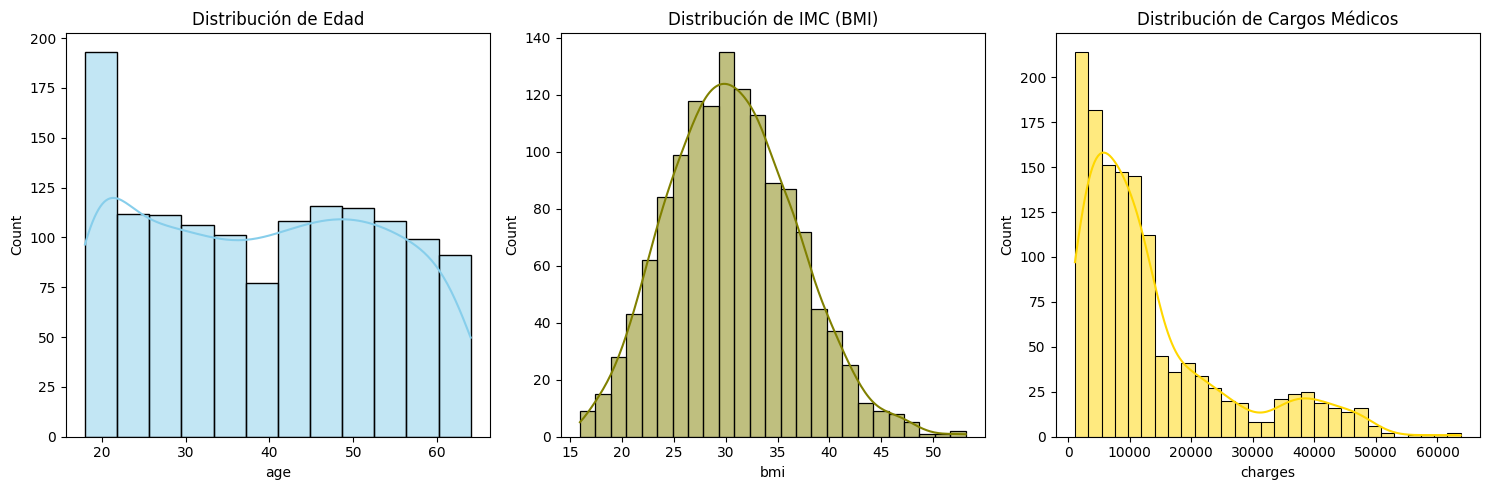

In [ ]:
# 4. Histogramas para 3 variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

sns.histplot(df['bmi'], kde=True, ax=axes[1], color='olive')
axes[1].set_title('Distribución de IMC (BMI)')

sns.histplot(df['charges'], kde=True, ax=axes[2], color='gold')
axes[2].set_title('Distribución de Cargos Médicos')

plt.tight_layout()
plt.show()

### Análisis de Histogramas de Variables Numéricas

Los histogramas visualizan la distribución de las variables numéricas clave:

*   **Distribución de Edad (age)**:
    *   El histograma de `age` muestra una distribución relativamente uniforme, con picos en las edades más jóvenes (alrededor de los 20 años) y luego una tendencia decreciente a medida que aumenta la edad. Hay una concentración notable de individuos en el rango de 20-30 años y otra más amplia hacia las edades medias. No parece haber un sesgo pronunciado en una dirección específica, lo que sugiere una buena representación de diferentes grupos de edad.

*   **Distribución de IMC (bmi)**:
    *   El histograma de `bmi` tiende a mostrar una distribución más bien normal, aunque ligeramente sesgada a la derecha. La mayoría de los individuos se encuentran en el rango de `bmi` considerado de sobrepeso a obesidad (alrededor de 25 a 35). También se pueden observar algunos valores extremos en los rangos más bajos y más altos de IMC. Sin embargo, tiene una forma muy campana de Gauss

*   **Distribución de Cargos Médicos (charges)**:
    *   El histograma de `charges` presenta una distribución altamente asimétrica positiva (sesgada a la derecha). Esto significa que la mayoría de los cargos médicos son relativamente bajos, pero hay una cola larga de valores, indicando que un número menor de individuos incurre en costos médicos muy elevados.

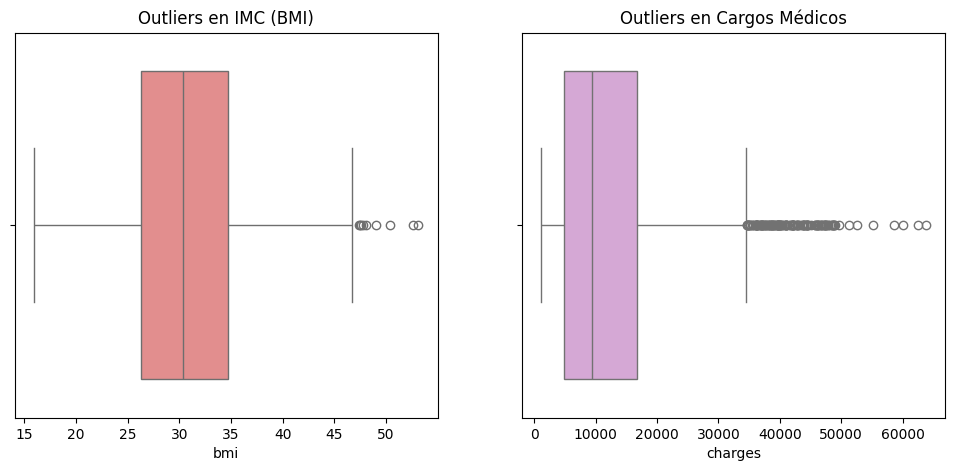

In [ ]:
# 5. Box plots para identificar outliers (ej. en BMI y Charges)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['bmi'], color='lightcoral')
plt.title('Outliers en IMC (BMI)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['charges'], color='plum')
plt.title('Outliers en Cargos Médicos')

plt.show()

### Análisis de Box Plots para Outliers

A continuación, se analiza lo observado en los Box plots de IMC y Cargos Médicos:

*   **Outliers en IMC (BMI)**:
    *   El Box plot para el `bmi` muestra una distribución central relativamente simétrica, lo que concuerda con el histograma. Sin embargo, se observan **varios puntos individuales más allá de los 'bigotes'**, tanto en la parte inferior como, más prominentemente, en la superior. Estos puntos representan valores de IMC que son significativamente más bajos o más altos que el grueso de la población, indicando la presencia de personas con bajo peso extremo o, más comúnmente, con obesidad severa.
    

*   **Outliers en Cargos Médicos (charges)**:
    *   El Box plot para `charges` confirma lo que ya decía el histograma: una **gran cantidad de valores atípicos, todos concentrados en la parte superior** (valores altos). Esto indica que, aunque la mayoría de los individuos incurren en costos médicos relativamente bajos, hay una porción de la población con gastos de seguro excepcionalmente elevados.

### Correlación entre variables

Para entender las relaciones entre las variables numéricas del dataset y ver cómo se relacionan con los cargos médicos, se generará una matriz de correlación visualizada con un mapa de calor.

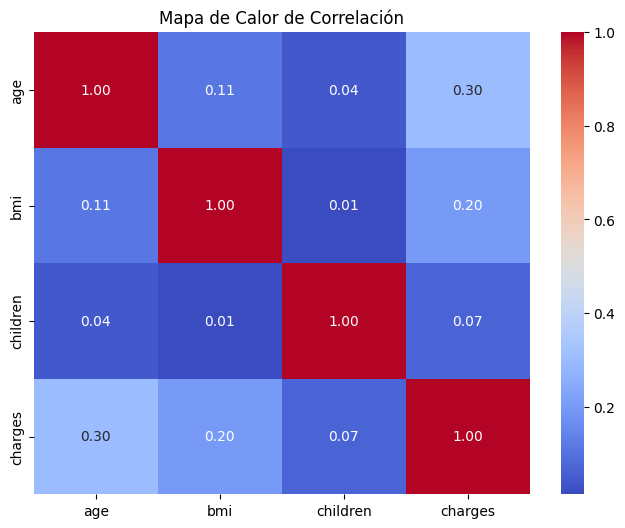

In [ ]:
# 6. Matriz de correlación (Heatmap)
plt.figure(figsize=(8, 6))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación')
plt.show()

### Análisis del Mapa de Calor de Correlación

El mapa de calor de correlación visualiza las relaciones lineales entre las variables numéricas del dataset. Los valores varían de -1 a 1, donde 1 indica una correlación positiva perfecta, -1 una correlación negativa perfecta, y 0 la ausencia de correlación.

**Observaciones clave:**

*   **Charges (Cargos médicos) y Age (Edad):** Existe una correlación positiva moderada (aproximadamente **0.30**) entre la edad y los cargos médicos. Esto sugiere que a medida que la edad aumenta, los costos médicos tienden a ser mayores.
*   **Charges (Cargos médicos) y BMI (IMC):** Se observa una correlación positiva débil (aproximadamente **0.20**) entre el IMC y los cargos. Aunque presente, la relación no es tan fuerte como con la edad.
*   **Charges (Cargos médicos) y Children (Hijos):** La correlación entre el número de hijos y los cargos médicos es muy débil (aproximadamente **0.07**), lo que indica que esta variable tiene poca influencia lineal directa en los costos.

En resumen, la **edad** es la variable numérica que muestra la correlación más fuerte con los cargos médicos, seguida por el **IMC**.

### Justificación del Análisis de Correlación: Edad vs. Cargos Médicos (Diferenciado por Fumador)

El análisis del mapa de calor de correlación reveló que la **edad** es la variable numérica con la relación lineal más fuerte con los **cargos médicos**. Para profundizar en esta relación y entender mejor cómo otros factores influyen, se ha decidido visualizar esta correlación con un gráfico de dispersión, diferenciando los puntos por la variable categórica **'smoker' (fumador)**.

Esta decisión se basa en las siguientes razones:

1.  **Correlación más Fuerte:** La edad mostró la correlación positiva más alta (aproximadamente 0.30) con los cargos médicos entre las variables numéricas, lo que sugiere que es un factor importante a considerar.
2.  **Influencia Conocida de 'smoker':** Es ampliamente sabido que ser fumador tiene un impacto significativo en los costos de salud. Al diferenciar el gráfico por esta variable, esperamos observar si la relación entre edad y cargos se comporta de manera diferente para fumadores y no fumadores.
3.  **Identificación de Patrones:** Este tipo de visualización nos permitirá identificar patrones o clústeres de datos. Por ejemplo, podríamos ver si los fumadores, independientemente de la edad, incurren en cargos médicos consistentemente más altos, o si el efecto de la edad en los cargos es más pronunciado en un grupo que en otro.

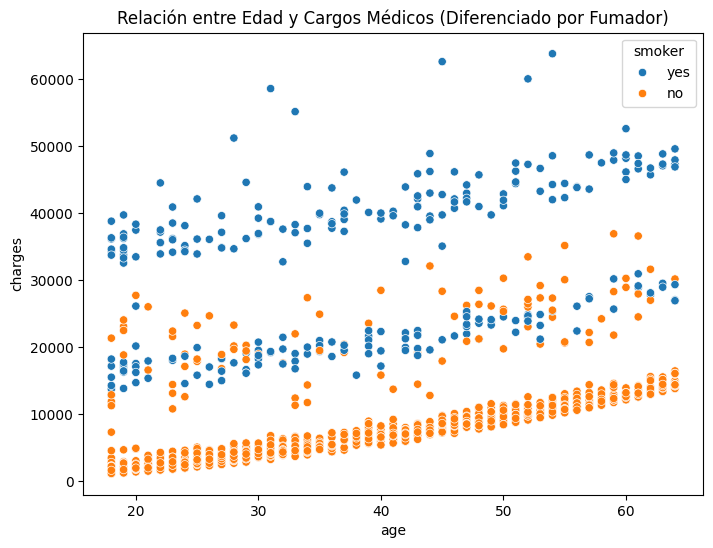

In [ ]:
# Scatter plot del par con mayor correlación (age y charges)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Relación entre Edad y Cargos Médicos (Diferenciado por Fumador)')
plt.show()

### Análisis del Gráfico de Dispersión: Edad vs. Cargos Médicos (Diferenciado por Fumador)

El gráfico de dispersión confirma visualmente la importancia de la edad y, de manera aún más destacada, del estado de fumador en la determinación de los cargos médicos. Se observan los siguientes patrones clave:

*   **Relación Edad-Cargos para No Fumadores (azul):** Para las personas que no fuman, se puede apreciar una correlación positiva moderada entre la edad y los cargos médicos. A medida que la edad aumenta, los cargos tienden a incrementarse, aunque el rango de variación es considerable.

*   **Relación Edad-Cargos para Fumadores (naranja):** En contraste, las personas que fuman experimentan cargos médicos consistentemente y significativamente más altos en comparación con los no fumadores, independientemente de su edad. La nube de puntos naranjas se sitúa claramente por encima de la de los no fumadores. Dentro del grupo de fumadores, también se observa una tendencia general de aumento de cargos con la edad.

*   **Impacto de 'smoker' como Factor Dominante:** La diferencia en los cargos entre fumadores y no fumadores es drástica y evidente. Ser fumador parece ser el factor más influyente en el nivel de los cargos médicos, superando incluso la influencia de la edad. Para cualquier edad dada, los fumadores tienen costos substancialmente mayores.

**Conclusión:** Este gráfico resalta que, si bien la edad tiene una correlación con los cargos médicos, el estado de fumador actúa como un factor multiplicador masivo de esos costos, siendo un predictor mucho más fuerte de los gastos de salud.